In [77]:
import torch
from torch import nn
from torch.utils.data import random_split, DataLoader, Subset
from torchvision import datasets
from torchvision.transforms import ToTensor
import numpy as np
import os
import pandas as pd
from torch.utils.data import Dataset
import sklearn
from sklearn.model_selection import train_test_split
from torchvision.transforms import ToTensor, Lambda
import matplotlib.colors as mcolors

from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold

import matplotlib.pyplot as plt
import wandb

In [73]:
import wandb

# Start a new wandb run to track this script.
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="elena-gonzalez-northwestern-university",
    # Set the wandb project where this run will be logged.
    project="ML_SPH_NN",
    name="W100_l3_b128_cross_validation",
    # Track hyperparameters and run metadata.
    config={
        "learning_rate": 0.1,
        "architecture": "NN",
        "dataset": "FB",
        "epochs": 1000,
        "width": 1000, 
        "layers": 3,
        "batch_size": 128
    },
)


In [74]:
#This is in place to fix all variables so I can gauge how effective changes are 

torch.manual_seed(42)
np.random.seed(42)

# Make training deterministic
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


#### **Put data into a database**

In [75]:

class CustomDataset(Dataset):
    def __init__(self, labels, data, dir, transform=None, target_transform=None):
        self.labels = labels
        self.data = data
        self.dir = dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        data = self.data[idx]
        label = self.labels[idx]
        if self.transform:
            data = self.transform(data)
        if self.target_transform:
            label = self.target_transform(label)
                    
        data = torch.from_numpy(data).type(torch.float)
        
        return data, label

In [76]:
# Create the dataset
data_dir = 'data.csv'
labels_file = 'data_labels.csv'

x_data  = np.loadtxt('data.csv', delimiter=',', dtype=float, skiprows = 1)
y_data  = np.loadtxt('data_labels.csv', delimiter=',', dtype=float, skiprows = 1).astype(np.int64)

#Feature transform: log the x-data
x_data[x_data <= 0] = 1e-4 #replace 0s by small numbers so log doesn't go to inf
x_data[:2, :] = np.log10(x_data[:2, :])
#Log only the velocities 
# x_data[1, :] = np.log10(x_data[1, :])

print(np.shape(x_data), np.shape(y_data))
#Save the original input for later 
x_data_og = x_data
X_train, X_test, y_train, y_test = train_test_split(x_data.T, y_data, test_size=0.20, stratify = y_data, random_state=42)

# Define the transform - One-Hot encoded
transform = None
target_transform = Lambda(lambda y: torch.zeros(3, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))

# Create separate datasets for train and test
train_dataset = CustomDataset(dir=data_dir, labels = y_train, data = X_train, transform=transform, target_transform = target_transform)
test_dataset = CustomDataset(dir=data_dir, labels = y_test, data = X_test, transform=transform, target_transform = target_transform)


#Take this out for final iteration, it is here to make sure data is shuffled the same each time
g = torch.Generator()
g.manual_seed(42)

train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True, generator=g)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=True, generator=g)
#TODO: Think about batching

for batch_data, batch_labels in train_dataloader:
    print("Batch data shape:", batch_data.shape)   # Correct way to check shape
    print("Batch labels shape:", batch_labels.shape)
    # print(batch_data)


(4, 14187) (14187,)
Batch data shape: torch.Size([128, 4])
Batch labels shape: torch.Size([128, 3])
Batch data shape: torch.Size([128, 4])
Batch labels shape: torch.Size([128, 3])
Batch data shape: torch.Size([128, 4])
Batch labels shape: torch.Size([128, 3])
Batch data shape: torch.Size([128, 4])
Batch labels shape: torch.Size([128, 3])
Batch data shape: torch.Size([128, 4])
Batch labels shape: torch.Size([128, 3])
Batch data shape: torch.Size([128, 4])
Batch labels shape: torch.Size([128, 3])
Batch data shape: torch.Size([128, 4])
Batch labels shape: torch.Size([128, 3])
Batch data shape: torch.Size([128, 4])
Batch labels shape: torch.Size([128, 3])
Batch data shape: torch.Size([128, 4])
Batch labels shape: torch.Size([128, 3])
Batch data shape: torch.Size([128, 4])
Batch labels shape: torch.Size([128, 3])
Batch data shape: torch.Size([128, 4])
Batch labels shape: torch.Size([128, 3])
Batch data shape: torch.Size([128, 4])
Batch labels shape: torch.Size([128, 3])
Batch data shape: to

### **Build Neural Network**

In [68]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(4, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, 3),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [69]:


def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for X, y in dataloader:

        # Compute prediction error
        pred = model(X)

        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # Log metrics to wandb.
        accuracy = (pred.argmax(dim = 1) == y.argmax(dim = 1)).type(torch.float).sum().item()
        accuracy /= size
        y = y.argmax(dim=1)
        balanced_acc = balanced_accuracy_score(y.numpy(), pred.argmax(dim = 1).numpy())
        
        run.log({"train_acc": 100*accuracy, "train_balanced_acc": 100*balanced_acc, "train_loss": loss.item()})

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    y_true = [] # Store labels for balanced accuracy
    y_pred = []  # Store labels for balanced accuracy
    with torch.no_grad():
        for X, y in dataloader:
            # X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            # print(pred.shape, y.shape)
            correct += (pred.argmax(dim = 1) == y.argmax(dim = 1)).type(torch.float).sum().item()
            # Store predictions and true labels
            y_true.extend(y.argmax(dim = 1).numpy())  # Convert tensors to NumPy
            y_pred.extend(pred.argmax(dim = 1).numpy())

    test_loss /= num_batches
    correct /= size
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Balanced Accuracy: {(100*balanced_acc):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    
    # Log metrics to wandb.
    run.log({"test_acc": 100*correct, "test_balanced_acc": 100*balanced_acc, "test_loss": test_loss})

    return test_loss



NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=4, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=50, bias=True)
    (3): ReLU()
    (4): Linear(in_features=50, out_features=3, bias=True)
  )
)


In [70]:
epochs = 1000
loss_history = []
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)


model = NeuralNetwork()
model = model.float()

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)


for fold, (train_idx, val_idx) in enumerate(skf.split(X, y.argmax(axis=1))):
    
    # Subset dataloaders
    train_loader = DataLoader(Subset(train_dataloader, train_idx), batch_size=64, shuffle=True)
    val_loader   = DataLoader(Subset(train_dataloader, val_idx), batch_size=64, shuffle=False)

    for t in range(epochs):
        print(f"Epoch {t+1}\n-------------------------------")
        train(train_dataloader, model, loss_fn, optimizer)
        loss = test(test_dataloader, model, loss_fn)

        loss_history.append(loss)
    print("Done!")

# Finish the run and upload any remaining data.
run.finish()


Epoch 1
-------------------------------
Test Error: 
 Accuracy: 84.7%, Balanced Accuracy: 59.1%, Avg loss: 0.494325 

Epoch 2
-------------------------------
Test Error: 
 Accuracy: 83.4%, Balanced Accuracy: 57.9%, Avg loss: 0.518675 

Epoch 3
-------------------------------
Test Error: 
 Accuracy: 86.5%, Balanced Accuracy: 60.7%, Avg loss: 0.413376 

Epoch 4
-------------------------------
Test Error: 
 Accuracy: 85.5%, Balanced Accuracy: 60.9%, Avg loss: 0.407714 

Epoch 5
-------------------------------
Test Error: 
 Accuracy: 87.4%, Balanced Accuracy: 78.0%, Avg loss: 0.389634 

Epoch 6
-------------------------------
Test Error: 
 Accuracy: 85.1%, Balanced Accuracy: 79.9%, Avg loss: 0.427283 

Epoch 7
-------------------------------
Test Error: 
 Accuracy: 89.5%, Balanced Accuracy: 77.9%, Avg loss: 0.303869 

Epoch 8
-------------------------------
Test Error: 
 Accuracy: 88.7%, Balanced Accuracy: 72.3%, Avg loss: 0.298836 

Epoch 9
-------------------------------
Test Error: 
 Ac

/Users/elenagonzalez/miniconda3/envs/ML/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Test Error: 
 Accuracy: 91.7%, Balanced Accuracy: 93.2%, Avg loss: 0.182212 

Epoch 92
-------------------------------
Test Error: 
 Accuracy: 94.4%, Balanced Accuracy: 94.9%, Avg loss: 0.131625 

Epoch 93
-------------------------------
Test Error: 
 Accuracy: 91.0%, Balanced Accuracy: 71.7%, Avg loss: 0.284209 

Epoch 94
-------------------------------
Test Error: 
 Accuracy: 94.3%, Balanced Accuracy: 88.3%, Avg loss: 0.131054 

Epoch 95
-------------------------------
Test Error: 
 Accuracy: 95.4%, Balanced Accuracy: 92.3%, Avg loss: 0.116773 

Epoch 96
-------------------------------
Test Error: 
 Accuracy: 93.0%, Balanced Accuracy: 94.1%, Avg loss: 0.158947 

Epoch 97
-------------------------------
Test Error: 
 Accuracy: 95.2%, Balanced Accuracy: 95.0%, Avg loss: 0.123106 

Epoch 98
-------------------------------
Test Error: 
 Accuracy: 95.3%, Balanced Accuracy: 95.1%, Avg loss: 0.111503 

Epoch 99
-------------------------------
Test Error: 
 Accuracy: 93.9%, Balanced Accuracy

/Users/elenagonzalez/miniconda3/envs/ML/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Test Error: 
 Accuracy: 95.1%, Balanced Accuracy: 95.0%, Avg loss: 0.117454 

Epoch 160
-------------------------------
Test Error: 
 Accuracy: 92.8%, Balanced Accuracy: 93.4%, Avg loss: 0.174116 

Epoch 161
-------------------------------
Test Error: 
 Accuracy: 94.6%, Balanced Accuracy: 95.1%, Avg loss: 0.132479 

Epoch 162
-------------------------------
Test Error: 
 Accuracy: 95.6%, Balanced Accuracy: 93.3%, Avg loss: 0.115337 

Epoch 163
-------------------------------
Test Error: 
 Accuracy: 92.0%, Balanced Accuracy: 77.9%, Avg loss: 0.299691 

Epoch 164
-------------------------------
Test Error: 
 Accuracy: 95.2%, Balanced Accuracy: 89.3%, Avg loss: 0.116600 

Epoch 165
-------------------------------
Test Error: 
 Accuracy: 95.9%, Balanced Accuracy: 94.2%, Avg loss: 0.101836 

Epoch 166
-------------------------------
Test Error: 
 Accuracy: 95.9%, Balanced Accuracy: 95.2%, Avg loss: 0.100733 

Epoch 167
-------------------------------
Test Error: 
 Accuracy: 96.1%, Balanced 

...

/Users/elenagonzalez/miniconda3/envs/ML/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Test Error: 
 Accuracy: 96.4%, Balanced Accuracy: 92.3%, Avg loss: 0.097425 

Epoch 977
-------------------------------


/Users/elenagonzalez/miniconda3/envs/ML/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Test Error: 
 Accuracy: 95.7%, Balanced Accuracy: 94.6%, Avg loss: 0.135359 

Epoch 978
-------------------------------
Test Error: 
 Accuracy: 95.9%, Balanced Accuracy: 93.0%, Avg loss: 0.140427 

Epoch 979
-------------------------------
Test Error: 
 Accuracy: 97.1%, Balanced Accuracy: 94.9%, Avg loss: 0.081485 

Epoch 980
-------------------------------
Test Error: 
 Accuracy: 97.5%, Balanced Accuracy: 95.9%, Avg loss: 0.074776 

Epoch 981
-------------------------------
Test Error: 
 Accuracy: 97.4%, Balanced Accuracy: 97.2%, Avg loss: 0.083822 

Epoch 982
-------------------------------
Test Error: 
 Accuracy: 97.2%, Balanced Accuracy: 96.2%, Avg loss: 0.079388 

Epoch 983
-------------------------------
Test Error: 
 Accuracy: 95.3%, Balanced Accuracy: 91.5%, Avg loss: 0.125306 

Epoch 984
-------------------------------
Test Error: 
 Accuracy: 97.3%, Balanced Accuracy: 94.9%, Avg loss: 0.078500 

Epoch 985
-------------------------------
Test Error: 
 Accuracy: 96.8%, Balanced 

test_acc,▄▆▆▅▇▇▇▇▆▇▆▅▁▆▂▆▇▇█▆▃██▇▇▇▇▇▇▇▇▇█▇▇█▇███
test_balanced_acc,▁▆▇▆▇▇▇██▇█▇█▇▇▇▇█▇██▇███▇█████▇████▇▇█▇
test_loss,█▇▆▆▄▄▃▄▂▂▆▂█▃▃▃▁▄▂▄▆▇▃▁▂▃▁▃▃▂▂▃▁▁▁▁▁▂▁▂
train_acc,██▇▇▇█▇▆▇▇█████▇▇██████▇▁▇█████▇███▇████
train_balanced_acc,▁▆▆▄█▇▄▇▆▆▇▅▇▆█▆▇▇▇█▇███▇████▆█▇████████
train_loss,█▄▇▅▅▂▂▅▃▅▂▃▆▃▂▅▄▂▃▃▅▃▃▄▃▁▅▂▂▃▃▃▆▂▂▂▅▂▁▂
test_acc,95.48978
test_balanced_acc,91.16876
test_loss,0.12313
train_acc,0.73134
train_balanced_acc,98.29004


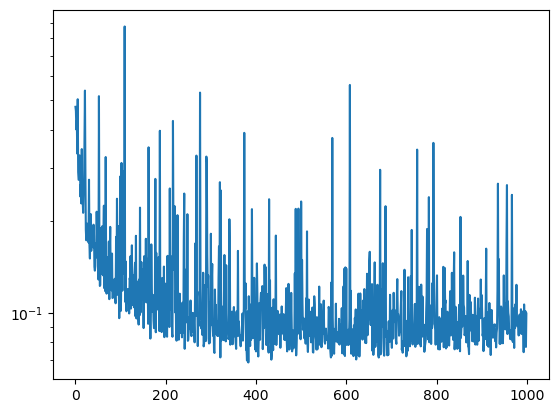

In [58]:
plt.plot(loss_history)
plt.yscale('log')


In [44]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


In [45]:

train_dataset.data = torch.from_numpy(train_dataset.data).type(torch.float)
train_dataset.labels = torch.from_numpy(train_dataset.labels).type(torch.float)
test_dataset.data = torch.from_numpy(test_dataset.data).type(torch.float)
test_dataset.labels = torch.from_numpy(test_dataset.labels).type(torch.float)

if isinstance(train_dataset.data, np.ndarray):
    print("X is a NumPy array")


[[1.         1.         1.         ... 0.4        0.5        0.7       ]
 [1.         1.         1.         ... 1.70000085 2.         2.5       ]]
(2, 290)


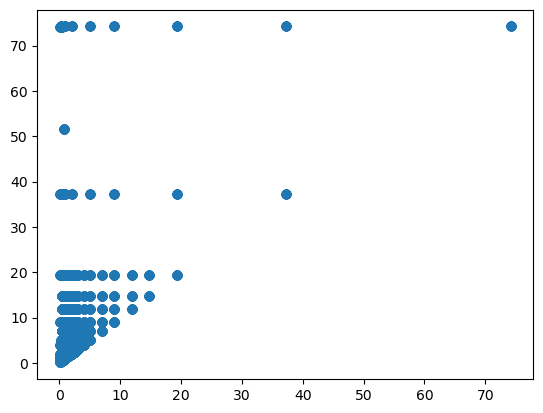

In [46]:
masses = x_data_og[2:,:]
masses[1, :] = masses[0, :] / masses[1, :]

plt.scatter(masses[0, :], masses[1, :])
print((masses))
unique_rows = np.unique(masses, axis=1)
print((np.shape(unique_rows)))

In [47]:
def plot_4d_decision_boundary(model, X_train, y_train, X_test, y_test, feature_idx=(0, 1), fixed_values={}, labels = []):
    """
    Plots the decision boundary for a PyTorch model using a 2D slice of a higher-dimensional space.
    
    Parameters:
    - model: Trained PyTorch model.
    -X, y:  data and labels.
    - feature_idx: Tuple (i, j) specifying which two features to plot.
    - fixed_values: Dictionary {feature_index: value} for fixing other dimensions.
    labels = list of strings 
    """

    # Step 1: Filter train and test data based on fixed_values
    
    train_mask= np.all([np.isclose(X_train[:, k], v, rtol = 0.09) for k, v in fixed_values.items()], axis=0)
    test_mask= np.all([np.isclose(X_test[:, k], v, rtol = 0.09) for k, v in fixed_values.items()], axis=0) 

    X_train_filtered, y_train_filtered = X_train[train_mask], y_train[train_mask]
    X_test_filtered, y_test_filtered = X_test[test_mask], y_test[test_mask]

    # Step 2: Create a meshgrid for the chosen two features
    x_min, x_max = X_train[:, feature_idx[0]].min() - 0.1, X_train[:, feature_idx[0]].max() + 0.1
    y_min, y_max = X_train[:, feature_idx[1]].min() - 0.1, X_train[:, feature_idx[1]].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    # Step 3: Construct full-dimensional input space for predictions
    X_vis = torch.zeros((xx.ravel().shape[0], X_train.shape[1]), dtype=torch.float32)
    X_vis[:, feature_idx[0]] = torch.tensor(xx.ravel(), dtype=torch.float32)
    X_vis[:, feature_idx[1]] = torch.tensor(yy.ravel(), dtype=torch.float32)

    # Assign fixed values to other dimensions
    for k, v in fixed_values.items():
        X_vis[:, k] = v

    # Step 4: Predict labels for meshgrid
    model.eval()
    with torch.no_grad():
        Z = model(X_vis).argmax(dim=1).numpy()
    Z = Z.reshape(xx.shape)

    # Normalize color mapping to match the scatter points and contour
    cmap = plt.cm.coolwarm  # Set the same colormap
    norm = mcolors.Normalize(vmin=y_train.min(), vmax=y_train.max())  # Normalize colors

    # Step 5: Plot decision boundary
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap, norm=norm)
    plt.scatter(X_train_filtered[:, feature_idx[0]], X_train_filtered[:, feature_idx[1]], c=y_train_filtered, cmap='coolwarm', edgecolor="k", marker='o', label = 'Train')
    plt.scatter(X_test_filtered[:, feature_idx[0]], X_test_filtered[:, feature_idx[1]], c=y_test_filtered, cmap='coolwarm', edgecolor="k", marker='x', label = 'Test')
    plt.xlabel(f" {labels[0]}")
    plt.ylabel(f" {labels[1]}")
    plt.legend()
    plt.title(f"NN: Decision Boundary Mass1 = {labels[2]} Msun , Mass2 = {labels[3]}Msun")
    plt.show()

In [48]:
# plot_4d_decision_boundary(model, train_dataset.data, train_dataset.labels, test_dataset.data, test_dataset.labels,feature_idx=(0, 1), fixed_values={2: 0.2, 3: round(0.2/74.21,2)}, labels = labels)

[1. 1.]


/var/folders/4h/5kpc_p3153q1gx8btc9x_3mc0000gn/T/ipykernel_37433/1235980194.py:48: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test_filtered[:, feature_idx[0]], X_test_filtered[:, feature_idx[1]], c=y_test_filtered, cmap='coolwarm', edgecolor="k", marker='x', label = 'Test')


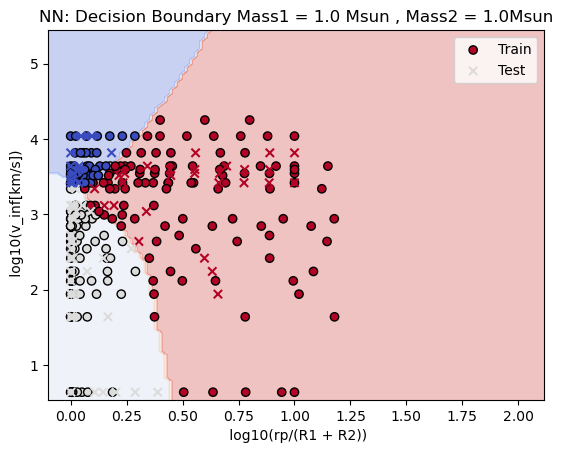

In [49]:

# unique_rows = unique_rows.T
unique_rows = np.array([[1.0,1.0]])
for unique in unique_rows:
    print(unique)
    Mass1 = unique[0]
    Mass2 = unique[1]
    # labels = ['log10(b[RSUN])', 'log10(v_inf[km/s])', str(Mass1), str(round(Mass2,2))]
    labels = ['log10(rp/(R1 + R2))', 'log10(v_inf[km/s])', str(Mass1), str(round(Mass2,2))]

    plot_4d_decision_boundary(model, train_dataset.data, train_dataset.labels, test_dataset.data, test_dataset.labels,feature_idx=(0, 1), fixed_values={2: Mass1, 3: Mass1/Mass2}, labels = labels)